In [2]:
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


QUESTION 1

In [ ]:
# Symmetry, intensity, label

def load_data(file_path):
    data = pd.read_csv(file_path, header=None)
    X = data.iloc[:, :2].values  # Converts 1st 2 columns into array
    y = data.iloc[:, 2].values   # Converts 3rd column into array
    y = np.where(y == 1, 1, -1)  # Convert labels (1 -> +1, 5 -> -1): np.where(condition, value_if_true, value_if_false)
    return X, y

1)

In [ ]:
def perceptron_train(X, y, epochs=5):
    n_samples, n_features = X.shape

    # Initialize weights and offset
    weights = np.zeros(n_features)
    bias = 0

    # Keep looping
    for _ in range(epochs):
        for i in range(n_samples):
            # If misclassified, update
            if y[i] * (np.dot(weights, X[i]) + bias) <= 0:
                weights += y[i] * X[i]
                bias += y[i]
    # End loop
    return weights, bias

def perceptron_predict(X, weights, bias):
    return np.sign(np.dot(X, weights) + bias)

def evaluate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

2)

In [ ]:
df_train='gdrive/My Drive/2025 50.007 ML HW1_final/data/hw1_train_1_5.csv'
df_test='gdrive/My Drive/2025 50.007 ML HW1_final/data/hw1_test_1_5.csv'
# Load train and test files
X_train, y_train = load_data(df_train)
X_test, y_test = load_data(df_test)

# Train Perceptron model
weights, bias = perceptron_train(X_train, y_train)

# Test model
y_pred = perceptron_predict(X_test, weights, bias)
accuracy = evaluate_accuracy(y_test, y_pred)

print("Perceptron Weights:", weights)
print("Perceptron Bias:", bias)
print("Training Error:", 1-accuracy)
print("Test Accuracy:", accuracy)

Perceptron Weights: [-2.05895878 -8.83521606]
Perceptron Bias: 1
Training Error: 0.03293413173652693
Test Accuracy: 0.9670658682634731


3)


In [ ]:
def ssgd(X, y, learning_rate=0.01, num_iterations=1000):
    # Add an offset term (bias) by appending a column of ones
    X = np.hstack((X, np.ones((X.shape[0], 1))))

    # Random Initialization
    w = np.zeros(X.shape[1])

    # Repeat until stopping criteria is met
    for _ in range(num_iterations):
        # Select t at random
        i = np.random.randint(0, len(y))
        xi, yi = X[i], y[i]

        # Compute hinge loss sub-gradient
        if yi * np.dot(w, xi) <= 1:
            gradient = -yi * xi  # Sub-gradient
        else:
            gradient = np.zeros_like(w)

        # Update
        w -= learning_rate * gradient

    return w

def compute_accuracy(X, y, w):
    X = np.hstack((X, np.ones((X.shape[0], 1))))  # Add bias term
    predictions = np.sign(np.dot(X, w))
    accuracy = np.mean(predictions == y)
    return accuracy

4)

In [ ]:
# Train classifier
w = ssgd(X_train, y_train, learning_rate=0.1, num_iterations=5000)

# Extract learned parameters
theta = w[:-1]  # Learned weights
theta_0 = w[-1]  # Learned bias

# Compute training error
train_predictions = np.sign(np.dot(np.hstack((X_train, np.ones((X_train.shape[0], 1)))), w))
training_error = np.mean(train_predictions != y_train)

# Compute test accuracy
test_accuracy = compute_accuracy(X_test, y_test, w)

# Print results
print("Learned weight vector (theta):", theta)
print("Learned bias (theta_0):", theta_0)
print("Training error:", training_error)
print("Test accuracy:", test_accuracy)

Learned weight vector (theta): [-3.59088478 -9.49677904]
Learned bias (theta_0): 2.7755575615628914e-17
Training error: 0.027466937945066123
Test accuracy: 0.9640718562874252


5) The training error for SSGD (0.0275) is lower compared to Perceptron (0.0329). This is because SSGD minimizes hinge loss and is ran for 500 iterations.

QUESTION 2


2)

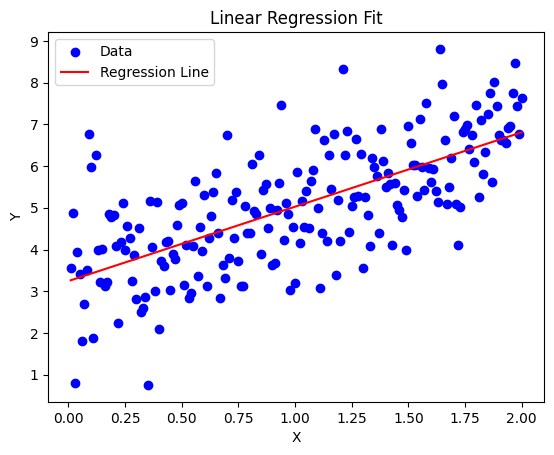

Error = 1.1625211505087873


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def load_data(x_file, y_file):
    x = np.loadtxt(x_file)
    y = np.loadtxt(y_file)
    return x, y

def closed_form_solution(x, y):
    x = x.reshape(-1, 1)  # Ensure x is a column vector
    X = np.c_[np.ones(x.shape[0]), x]  # Add bias term (column of ones)

    theta = np.linalg.inv(X.T @ X) @ X.T @ y  # Closed-form solution
    theta_0, theta_1 = theta[0], theta[1]
    return theta_0, theta_1

def plot_regression(x, y, theta_0, theta_1):
    plt.scatter(x, y, color='blue', label='Data')

    x_range = np.linspace(min(x), max(x), 100)
    y_pred = theta_0 + theta_1 * x_range
    plt.plot(x_range, y_pred, color='red', label='Regression Line')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Linear Regression Fit')
    plt.legend()
    plt.show()

def empirical_risk(x, y, theta_0, theta_1):
    y_pred = theta_0 + theta_1 * x
    mse = np.mean((y - y_pred) ** 2)
    return mse

x_train='gdrive/My Drive/2025 50.007 ML HW1_final/data/hw1_linear_x.dat'
y_train='gdrive/My Drive/2025 50.007 ML HW1_final/data/hw1_linear_y.dat'

x,y = load_data(x_train, y_train)
theta_0,theta_1 = closed_form_solution(x, y)
plot_regression(x, y, theta_0, theta_1)
print("Error =", empirical_risk(x, y, theta_0, theta_1))

3)

Iteration 1: θ0 = 0.10070403881800001, θ1 = 0.11308440461572, MSE = 25.331023713758768
Iteration 2: θ0 = 0.19712100032686403, θ1 = 0.22110641935238765, MSE = 23.28043101413293
Iteration 3: θ0 = 0.28943838010934375, θ1 = 0.3242882256927971, MSE = 21.40550329437
Iteration 4: θ0 = 0.37783545798873164, θ1 = 0.42284226710863093, MSE = 19.691181812466546
Iteration 5: θ0 = 0.46248365807807357, θ1 = 0.5169716758283698, MSE = 18.12369878795591


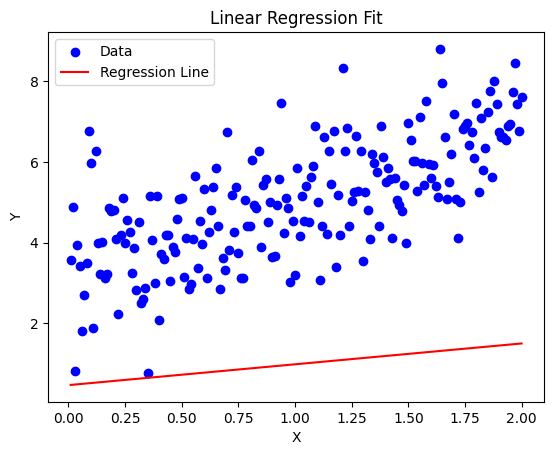

Error = 18.12369878795591


In [11]:
def gradient_descent(x, y, learning_rate, iterations):
    m = len(y)
    theta_0, theta_1 = 0, 0  # Initialize parameters
    X = np.c_[np.ones(x.shape[0]), x]  # Add bias term

    for i in range(iterations):
        y_pred = theta_0 + theta_1 * x
        gradient_0 = -(2/m) * np.sum(y - y_pred)
        gradient_1 = -(2/m) * np.sum((y - y_pred) * x)

        theta_0 -= learning_rate * gradient_0
        theta_1 -= learning_rate * gradient_1

        error = empirical_risk(x, y, theta_0, theta_1)
        print(f'Iteration {i+1}: θ0 = {theta_0}, θ1 = {theta_1}, MSE = {error}')

    return theta_0, theta_1

x,y = load_data(x_train, y_train)
theta_0,theta_1 = gradient_descent(x, y, 0.01, 5)
plot_regression(x, y, theta_0, theta_1)
print("Error =", empirical_risk(x, y, theta_0, theta_1))

4)

Epoch 1: θ0 = 2.6222125593477985, θ1 = 2.3981099545145828, MSE = 1.289232933147301
Epoch 2: θ0 = 2.8484541673867247, θ1 = 2.060244396131009, MSE = 1.2019096609449715
Epoch 3: θ0 = 3.0770503011440122, θ1 = 1.9628227492212378, MSE = 1.1736813847353005
Epoch 4: θ0 = 3.1749077708376214, θ1 = 1.87552287331697, MSE = 1.1660688421945093
Epoch 5: θ0 = 3.0544186281503127, θ1 = 1.7122987820568345, MSE = 1.2316806598373211


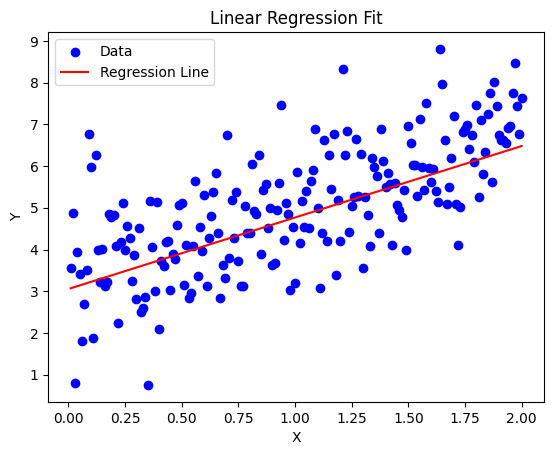

Error = 1.2316806598373211


In [13]:
def stochastic_gradient_descent(x, y, learning_rate=0.01, epochs=5):
    m = len(y)
    theta_0, theta_1 = 0, 0  # Initialize parameters

    for epoch in range(epochs):
        indices = np.random.permutation(m)  # Shuffle data with replacement
        for i in indices:
            y_pred = theta_0 + theta_1 * x[i]
            gradient_0 = -2 * (y[i] - y_pred)
            gradient_1 = -2 * (y[i] - y_pred) * x[i]

            theta_0 -= learning_rate * gradient_0
            theta_1 -= learning_rate * gradient_1

        error = empirical_risk(x, y, theta_0, theta_1)
        print(f'Epoch {epoch+1}: θ0 = {theta_0}, θ1 = {theta_1}, MSE = {error}')

    return theta_0, theta_1

x,y = load_data(x_train, y_train)
theta_0,theta_1 = stochastic_gradient_descent(x, y, 0.01, 5)
plot_regression(x, y, theta_0, theta_1)
print("Error =", empirical_risk(x, y, theta_0, theta_1))

QUESTION 3

1)


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def load_data(x_file, y_file):
  X = np.genfromtxt(x_file, delimiter=",")
  y = np.genfromtxt(y_file, delimiter=",")

  return x, y

def split(x,y):
  # Split into validation (first 10 entries) and training (last 40 entries)
  Xval = x[:10]
  yval = y[:10]
  Xtrain = x[-40:]
  ytrain = y[-40:]

  Xtrain = Xtrain.reshape(-1, 1)

  return Xval, yval, Xtrain, ytrain

def ridge_regression(Xtrain, ytrain, lamda):

    n_features = Xtrain.shape[1]  # Number of features
    I = np.eye(n_features)  # Identity matrix
    I[0, 0] = 0  # Exclude bias term from regularization (if needed)
    theta = np.linalg.inv(Xtrain.T @ Xtrain + lamda * I) @ Xtrain.T @ ytrain
    return theta


x_train='gdrive/My Drive/2025 50.007 ML HW1_final/data/hw1_ridge_x.dat'
y_train='gdrive/My Drive/2025 50.007 ML HW1_final/data/hw1_ridge_y.dat'

x,y = load_data(x_train, y_train)
Xval, yval, Xtrain, ytrain = split(x,y)
theta = ridge_regression(Xtrain, ytrain, 0.15)
print(f"θ = {theta}")

θ = [-0.92386454]


2)

Best λ that minimizes validation loss: 0


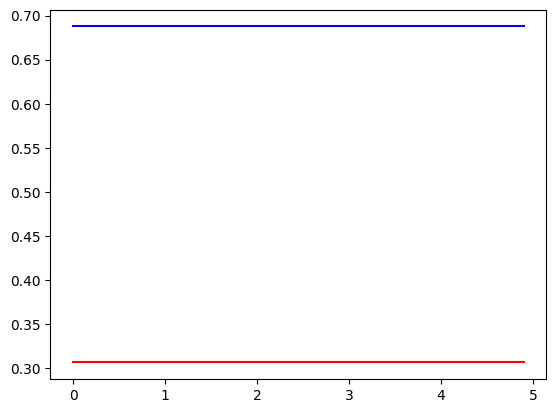

In [44]:
Xval = Xval.reshape(-1, 1) # Reshape Xval into a column vector
tn = Xtrain.shape[0]
vn = Xval.shape[0]
tloss = []
vloss = []
index = np.arange(0, 5, 0.1)

for i in index:
  w = ridge_regression(Xtrain, ytrain, 10**i)
  tloss = tloss + [np.sum((np.dot(Xtrain, w) - ytrain)**2) / tn / 2]
  vloss = vloss + [np.sum((np.dot(Xval, w) - yval)**2) / vn / 2]

plt.plot(index, np.log(tloss), 'r')
plt.plot(index, np.log(vloss), 'b')
best_lambda = np.argmin(vloss)
print("Best λ that minimizes validation loss:", best_lambda)